# SHAP: quali angoli guidano la classificazione?

Nessun numero qui e' scritto a mano: tutto viene da `results/shap/rehab24_anatomical.csv`, prodotto da `python src/run_shap.py --all`. Per ogni esercizio, quel runner prende il modello che ha vinto sulla famiglia `anatomical` in `results/experiments/experiments.csv` (letto, non deciso a mano), lo rispiega con permutation SHAP (stesso codice per logreg/rf/mlp) usando split raggruppati per soggetto ripetuti 5 volte - ogni campione e' spiegato solo da modelli che non lo hanno mai visto in training, la stessa regola anti-leakage della CV principale.

Domanda a cui questa analisi risponde: le feature anatomiche (angoli con nome) sono l'unica famiglia interpretabile del progetto - ma quali angoli specifici guidano davvero la decisione, esercizio per esercizio? E coincidono con l'intuizione clinica (es. valgismo del ginocchio negli squat)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

pd.set_option("display.width", 160)

df = pd.read_csv("../results/shap/rehab24_anatomical.csv")
shap_cols = [c for c in df.columns if c.startswith("shap__")]
feature_names = [c[len("shap__"):] for c in shap_cols]
value_cols = [f"value__{f}" for f in feature_names]

print(f"{df.shape[0]} campioni spiegati, {len(feature_names)} feature, esercizi: {sorted(df['exercise'].unique())}")
print(df[["exercise", "model"]].drop_duplicates().to_string(index=False))

595 campioni spiegati, 83 feature, esercizi: ['Ex1', 'Ex2', 'Ex3', 'Ex4', 'Ex5', 'Ex6']
exercise  model
     Ex1     rf
     Ex2     rf
     Ex3 logreg
     Ex4 logreg
     Ex5     rf
     Ex6 logreg


## Leaderboard: la feature che conta di piu', esercizio per esercizio

In [2]:
from scipy.stats import mannwhitneyu

leaderboard_rows = []
for ex in sorted(df["exercise"].unique()):
    sub = df[df["exercise"] == ex]
    mean_abs = sub[shap_cols].abs().mean()
    top_col = mean_abs.idxmax()
    top_feature = top_col[len("shap__"):]

    values = sub[f"value__{top_feature}"]
    g1, g0 = values[sub["correct"] == 1], values[sub["correct"] == 0]
    _, pval = mannwhitneyu(g1, g0)

    leaderboard_rows.append({"exercise": ex, "model": sub["model"].iloc[0],
                              "top_feature": top_feature, "mean_abs_shap": mean_abs.max(),
                              "univariate_p": pval, "n_samples": len(sub)})

leaderboard = pd.DataFrame(leaderboard_rows)
print(leaderboard.to_string(index=False, float_format="%.4f"))
print("\nunivariate_p: Mann-Whitney su valore grezzo della top feature SHAP vs correct/incorrect - "
      "se e' alto, il modello considera importante una feature che da sola non separa le classi, "
      "un segnale di interazione piuttosto che di effetto diretto.")

exercise  model                   top_feature  mean_abs_shap  univariate_p  n_samples
     Ex1     rf                  r_ankle_mean         0.0235        0.0003         88
     Ex2     rf          l_ankle_vel_mean_abs         0.0253        0.0000        109
     Ex3 logreg                     sym_elbow         0.0354        0.0000         96
     Ex4 logreg l_shoulder_angle_vel_mean_abs         0.0212        0.0000        116
     Ex5     rf          r_ankle_vel_mean_abs         0.0413        0.0000         88
     Ex6 logreg                   l_knee_mean         0.0247        0.0000         98

univariate_p: Mann-Whitney su valore grezzo della top feature SHAP vs correct/incorrect - se e' alto, il modello considera importante una feature che da sola non separa le classi, un segnale di interazione piuttosto che di effetto diretto.


## Ranking globale: quali feature contano di piu', in media su tutti gli esercizi?

r_ankle_vel_mean_abs            0.0136
l_ankle_min                     0.0118
l_ankle_vel_mean_abs            0.0117
l_shoulder_angle_rom            0.0109
l_ankle_mean                    0.0107
r_ankle_vel_max_abs             0.0102
l_shoulder_angle_vel_mean_abs   0.0101
sym_hip                         0.0100
l_shoulder_angle_std            0.0097
trunk_flex_mean                 0.0095
r_hip_vel_mean_abs              0.0094
sym_elbow                       0.0092
trunk_flex_min                  0.0091
l_shoulder_angle_vel_max_abs    0.0085
r_ankle_mean                    0.0083
l_hip_std                       0.0081
l_knee_vel_mean_abs             0.0080
r_hip_rom                       0.0076
trunk_flex_vel_mean_abs         0.0075
l_knee_mean                     0.0074


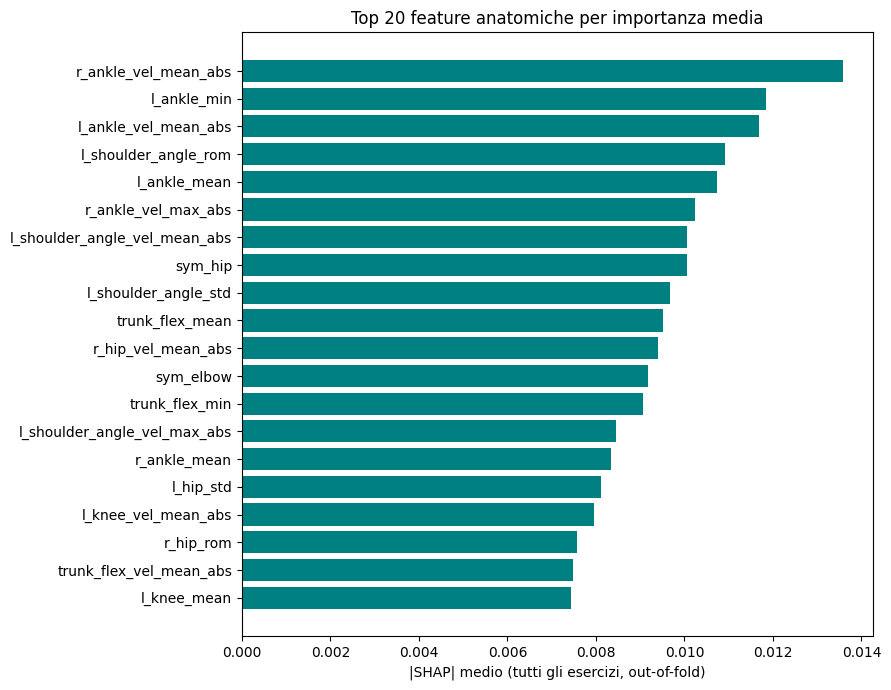

In [3]:
mean_abs_shap = df[shap_cols].abs().mean().sort_values(ascending=False)
mean_abs_shap.index = [i[len("shap__"):] for i in mean_abs_shap.index]

print(mean_abs_shap.head(20).to_string(float_format="%.4f"))

fig, ax = plt.subplots(figsize=(9, 7))
top20 = mean_abs_shap.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color="teal")
ax.set_xlabel("|SHAP| medio (tutti gli esercizi, out-of-fold)")
ax.set_title("Top 20 feature anatomiche per importanza media")
plt.tight_layout()
plt.show()

## Per esercizio: bar chart di importanza + beeswarm

Il bar chart mostra |SHAP| medio (quanto una feature sposta la predizione, in media, indipendentemente dalla direzione). Il beeswarm aggiunge la direzione: ogni punto e' un campione, colore=valore della feature (rosso=alto, blu=basso), posizione orizzontale=impatto SHAP sulla probabilita' di 'corretto'.


Ex1 (modello: rf, n=88) - top 12 feature:
             feature  mean_abs_shap
        r_ankle_mean         0.0235
         r_ankle_max         0.0234
             sym_hip         0.0210
         r_knee_mean         0.0210
          r_knee_min         0.0174
          r_knee_max         0.0173
           l_hip_std         0.0165
 r_elbow_vel_max_abs         0.0148
         r_ankle_min         0.0130
           l_hip_rom         0.0124
            sym_knee         0.0115
r_elbow_vel_mean_abs         0.0105


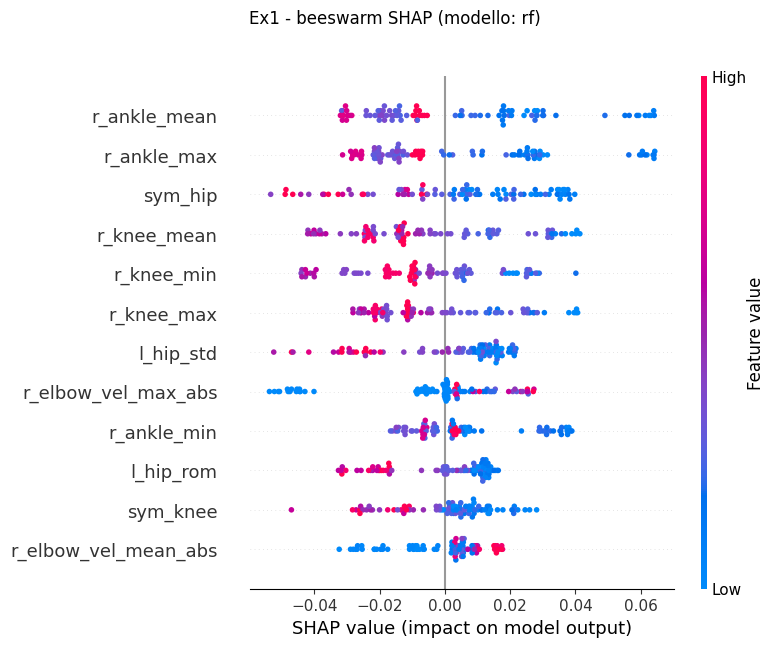


Ex2 (modello: rf, n=109) - top 12 feature:
                feature  mean_abs_shap
   l_ankle_vel_mean_abs         0.0253
   r_ankle_vel_mean_abs         0.0245
    l_knee_vel_mean_abs         0.0228
     r_hip_vel_mean_abs         0.0218
      r_hip_vel_max_abs         0.0174
trunk_flex_vel_mean_abs         0.0171
    r_ankle_vel_max_abs         0.0167
     l_hip_vel_mean_abs         0.0163
   l_shoulder_angle_rom         0.0155
              r_hip_max         0.0146
                sym_hip         0.0141
    l_ankle_vel_max_abs         0.0134


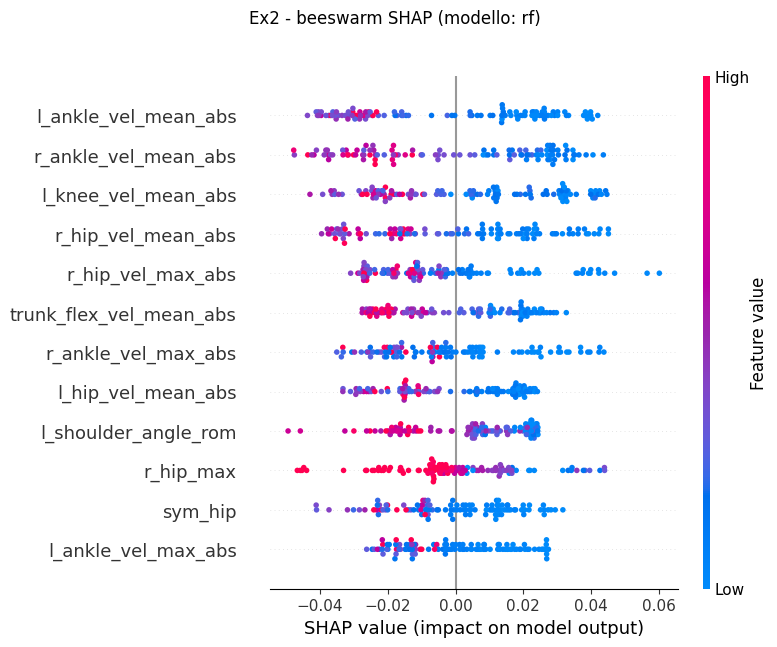


Ex3 (modello: logreg, n=96) - top 12 feature:
             feature  mean_abs_shap
           sym_elbow         0.0354
        l_elbow_mean         0.0278
     trunk_flex_mean         0.0257
           r_hip_rom         0.0257
      trunk_flex_max         0.0253
           r_hip_std         0.0230
             sym_hip         0.0222
         l_elbow_std         0.0180
l_shoulder_angle_std         0.0177
      trunk_flex_min         0.0170
         l_elbow_min         0.0169
l_shoulder_angle_max         0.0168


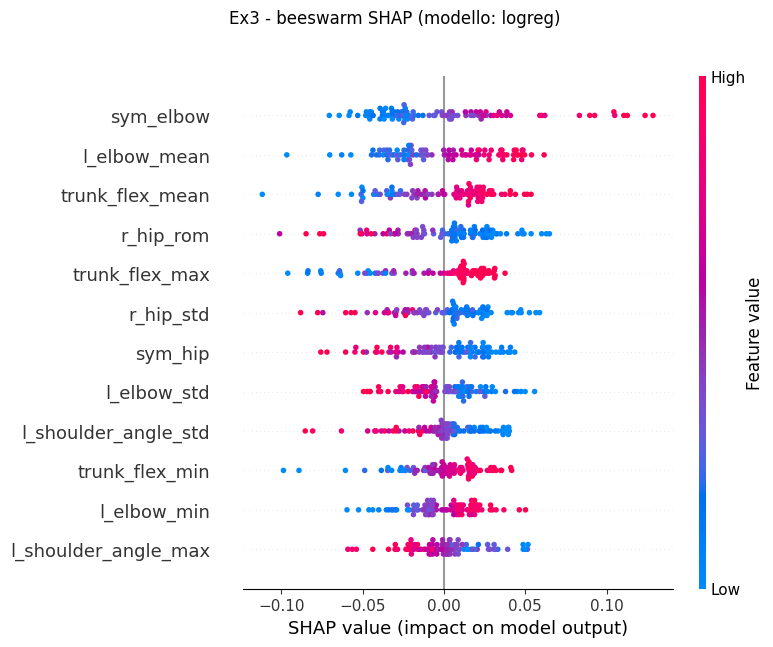


Ex4 (modello: logreg, n=116) - top 12 feature:
                      feature  mean_abs_shap
l_shoulder_angle_vel_mean_abs         0.0212
         l_shoulder_angle_std         0.0185
         l_shoulder_angle_rom         0.0178
               trunk_flex_min         0.0159
              trunk_flex_mean         0.0140
                  l_ankle_min         0.0123
         r_shoulder_angle_std         0.0122
         l_ankle_vel_mean_abs         0.0120
                  l_ankle_std         0.0118
           r_hip_vel_mean_abs         0.0118
         l_shoulder_angle_max         0.0116
                   r_knee_min         0.0115


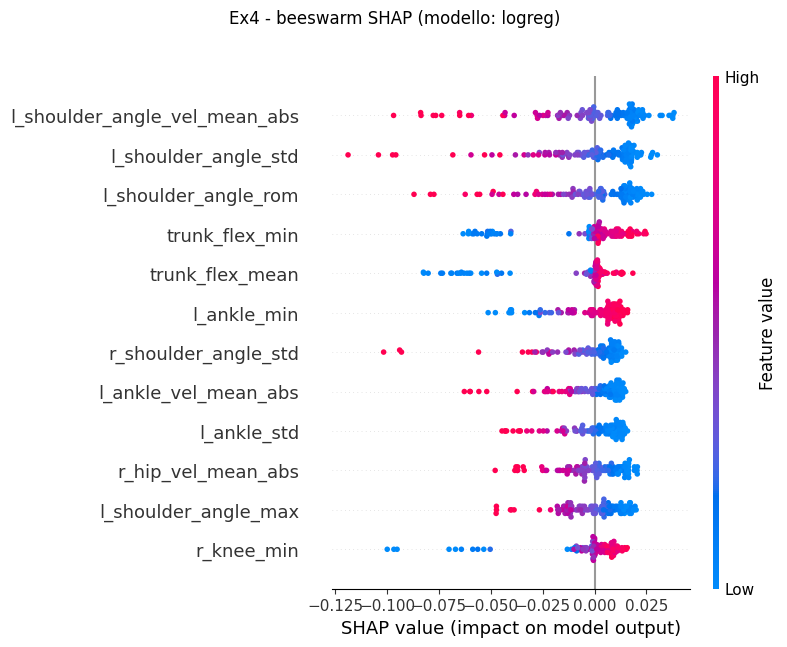


Ex5 (modello: rf, n=88) - top 12 feature:
             feature  mean_abs_shap
r_ankle_vel_mean_abs         0.0413
         l_ankle_min         0.0321
 r_ankle_vel_max_abs         0.0242
l_ankle_vel_mean_abs         0.0222
 r_knee_vel_mean_abs         0.0200
        l_ankle_mean         0.0170
           l_hip_std         0.0167
         l_ankle_rom         0.0119
         r_ankle_rom         0.0119
         l_ankle_std         0.0111
         r_ankle_std         0.0100
 l_ankle_vel_max_abs         0.0097


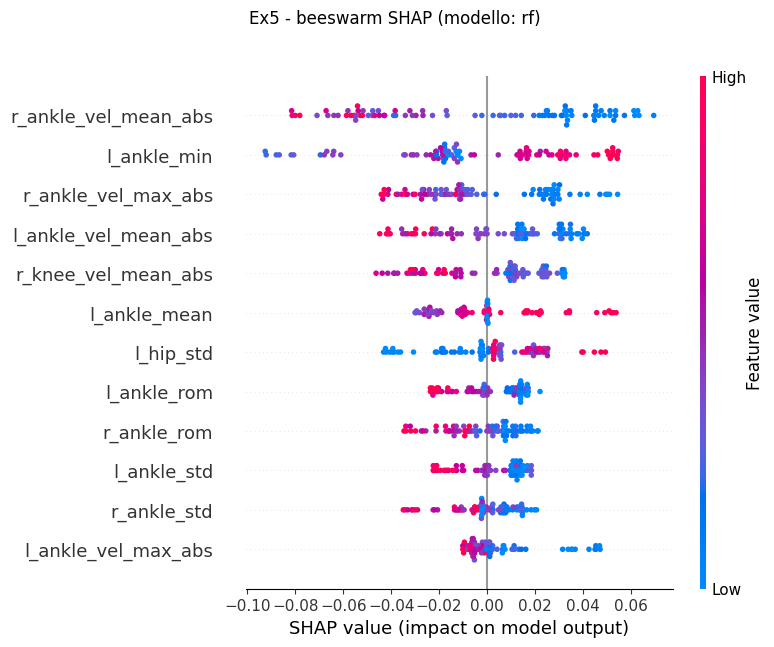


Ex6 (modello: logreg, n=98) - top 12 feature:
             feature  mean_abs_shap
         l_knee_mean         0.0247
r_shoulder_angle_min         0.0215
        l_ankle_mean         0.0213
         l_ankle_min         0.0209
     knee_valgus_min         0.0167
 r_ankle_vel_max_abs         0.0160
      trunk_flex_std         0.0147
r_ankle_vel_mean_abs         0.0139
         r_ankle_min         0.0137
         r_knee_mean         0.0133
    knee_valgus_mean         0.0126
          r_knee_std         0.0126


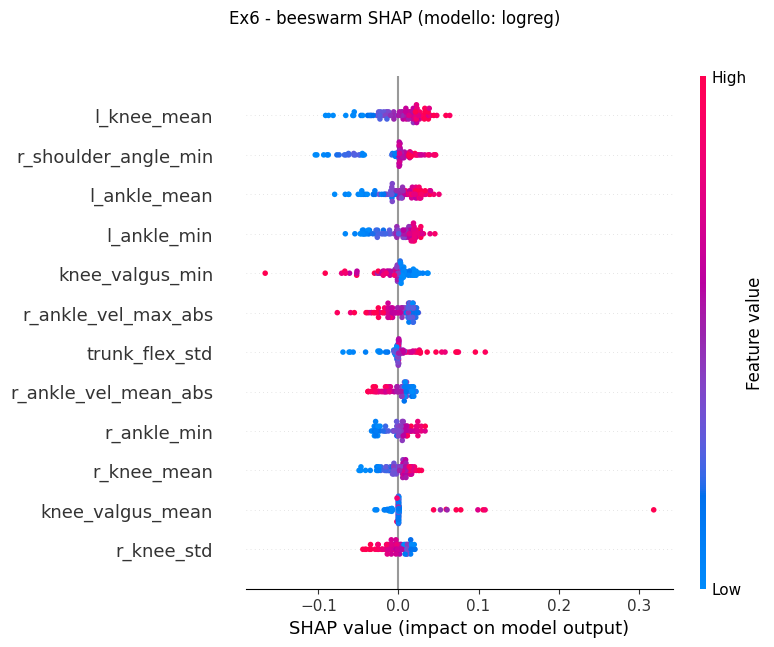

In [4]:
N_TOP = 12

for ex in sorted(df["exercise"].unique()):
    sub = df[df["exercise"] == ex]
    model_name = sub["model"].iloc[0]
    shap_vals = sub[shap_cols].values
    data_vals = sub[value_cols].values

    mean_abs = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs)[::-1][:N_TOP]

    print(f"\n{ex} (modello: {model_name}, n={len(sub)}) - top {N_TOP} feature:")
    top_table = pd.DataFrame({"feature": np.array(feature_names)[order],
                              "mean_abs_shap": mean_abs[order]})
    print(top_table.to_string(index=False, float_format="%.4f"))

    expl = shap.Explanation(values=shap_vals[:, order], data=data_vals[:, order],
                             feature_names=list(np.array(feature_names)[order]))
    shap.plots.beeswarm(expl, max_display=N_TOP, show=False)
    fig = plt.gcf()
    fig.suptitle(f"{ex} - beeswarm SHAP (modello: {model_name})", y=1.02)
    plt.tight_layout()
    plt.show()

## Coerenza tra esercizi: le stesse feature contano ovunque o e' tutto specifico per esercizio?

In [5]:
top5_by_ex = {}
for ex in sorted(df["exercise"].unique()):
    sub = df[df["exercise"] == ex]
    mean_abs = sub[shap_cols].abs().mean()
    mean_abs.index = feature_names
    top5_by_ex[ex] = set(mean_abs.sort_values(ascending=False).head(5).index)

from collections import Counter
appearances = Counter(f for top5 in top5_by_ex.values() for f in top5)
consistency = pd.Series(appearances).sort_values(ascending=False)
print("Quante volte (su 6 esercizi) ogni feature compare nella top-5 locale:")
print(consistency.to_string())

print("\nTop-5 per esercizio:")
for ex, feats in top5_by_ex.items():
    print(f"  {ex}: {sorted(feats)}")

Quante volte (su 6 esercizi) ogni feature compare nella top-5 locale:
r_ankle_vel_mean_abs             2
l_ankle_vel_mean_abs             2
l_ankle_min                      2
trunk_flex_mean                  2
r_ankle_max                      1
r_knee_mean                      1
r_hip_vel_mean_abs               1
r_ankle_mean                     1
r_knee_min                       1
sym_hip                          1
r_hip_vel_max_abs                1
l_knee_vel_mean_abs              1
trunk_flex_max                   1
l_elbow_mean                     1
sym_elbow                        1
l_shoulder_angle_vel_mean_abs    1
trunk_flex_min                   1
r_hip_rom                        1
l_shoulder_angle_rom             1
l_shoulder_angle_std             1
r_ankle_vel_max_abs              1
r_knee_vel_mean_abs              1
l_ankle_mean                     1
r_shoulder_angle_min             1
knee_valgus_min                  1
l_knee_mean                      1

Top-5 per esercizio

## Le fasi del movimento aggiungono qualcosa? (famiglia biophases)

Stesso identico procedimento (`python src/run_shap.py --all --family biophases`), ma su feature suddivise per fase (`descent__`, `bottom__`, `ascent__`, 216 invece di 86) invece che sull'intera ripetizione. Se una feature conta soprattutto in una fase specifica, qui dovrebbe emergere; se il segnale e' diffuso su tutta la ripetizione, la versione anatomical bastava gia'.

In [6]:
df_bio = pd.read_csv("../results/shap/rehab24_biophases.csv")
shap_cols_bio = [c for c in df_bio.columns if c.startswith("shap__")]

leaderboard_bio_rows = []
for ex in sorted(df_bio["exercise"].unique()):
    sub = df_bio[df_bio["exercise"] == ex]
    mean_abs = sub[shap_cols_bio].abs().mean()
    top_col = mean_abs.idxmax()
    leaderboard_bio_rows.append({"exercise": ex, "model": sub["model"].iloc[0],
                                  "top_feature": top_col[len("shap__"):],
                                  "mean_abs_shap": mean_abs.max(), "n_samples": len(sub)})

leaderboard_bio = pd.DataFrame(leaderboard_bio_rows)
print(leaderboard_bio.to_string(index=False, float_format="%.4f"))

exercise  model                  top_feature  mean_abs_shap  n_samples
     Ex1     rf          bottom__r_ankle_max         0.0143         88
     Ex2     rf  ascent__l_knee_vel_mean_abs         0.0184        109
     Ex3 logreg  bottom__l_knee_vel_mean_abs         0.0217         96
     Ex4     rf descent__l_knee_vel_mean_abs         0.0192        116
     Ex5 logreg         descent__l_knee_mean         0.0246         88
     Ex6 logreg        descent__l_ankle_mean         0.0149         98


### Il segnale di `knee_valgus_min` (Ex6) sopravvive alla suddivisione per fase?

La famiglia anatomical (non suddivisa per fase) mostra `knee_valgus_min` tra le prime 5 feature
per Ex6 (vedi sopra), non come singola feature dominante. Con 216 feature invece di 83 il
ranking assoluto puo' cambiare per semplice diluizione statistica (piu' feature tra cui
competere) - qui si controlla direttamente dove va a finire quella stessa feature, ora divisa
in tre versioni per fase.

In [7]:
sub_ex6 = df_bio[df_bio["exercise"] == "Ex6"]
mean_abs_ex6 = sub_ex6[shap_cols_bio].abs().mean().sort_values(ascending=False)
mean_abs_ex6.index = [i[len("shap__"):] for i in mean_abs_ex6.index]

valgus_rows = [{"feature": f, "rank": list(mean_abs_ex6.index).index(f) + 1,
                 "mean_abs_shap": mean_abs_ex6[f]}
               for f in mean_abs_ex6.index if "valgus_min" in f]
print(pd.DataFrame(valgus_rows).to_string(index=False, float_format="%.4f"))
print(f"\n(su {len(mean_abs_ex6)} feature totali)")

                 feature  rank  mean_abs_shap
descent__knee_valgus_min    10         0.0084
 ascent__knee_valgus_min    36         0.0050
 bottom__knee_valgus_min    50         0.0040

(su 216 feature totali)


## Lettura onesta

**Coincide con l'intuizione clinica?** Parzialmente. Su Ex6 (squat), `knee_valgus_min` - la
feature costruita apposta per catturare il cedimento verso l'interno del ginocchio, un classico
marker di qualita' nello squat/affondo in letteratura - compare al 5o posto su 83, non al primo:
il modello si affida di piu' a `l_knee_mean` (quanto si flette il ginocchio in media durante la
ripetizione, una misura piu' generica di profondita'/range) che al proxy specifico del
valgismo. Il segnale del valgismo c'e' ed e' reale (confermato anche divisa per fase: 10/216 in
descent), ma non e' la storia dominante che un'aspettativa clinica ingenua suggerirebbe - e'
riportato cosi' com'e', non aggiustato per farlo combaciare con l'intuizione.

**Il ranking e' condiviso tra esercizi o e' tutto specifico?** Molto specifico: nessuna feature
compare nella top-5 locale di piu' di 2 esercizi su 6, e la maggioranza compare in uno solo.
Le uniche a ricorrere due volte sono legate a caviglia e tronco (`r_ankle_vel_mean_abs`,
`l_ankle_vel_mean_abs`, `l_ankle_min`, `trunk_flex_mean`) - non c'e' ancora un vocabolario
comune di qualita' del movimento, ogni esercizio sembra giudicato su un proprio set di segnali.
Con 6 esercizi e questi campioni, non e' possibile distinguere "davvero specifico per esercizio"
da "coincidenza su un campione piccolo".

**Un'osservazione da non sovra-interpretare**: su Ex1 (arm abduction, un esercizio di braccia)
le feature dominanti sono caviglia e ginocchio (`r_ankle_mean`, `r_ankle_max`, `r_knee_mean`),
non il braccio - nessuna feature di spalla compare nella top-12. Questo e' meno intuitivo del
risultato di Ex6: non corrisponde a un pattern clinico di compensazione tronco/spalla
conosciuto, quindi va segnalato come osservazione aperta, non spiegato con una lettura clinica
di comodo - puo' riflettere un confondimento reale (es. postura/appoggio che cambia insieme
alla qualita' del movimento del braccio) oppure un artefatto del campione ridotto, e qui non e'
possibile distinguere le due cose.

Nota metodologica: questa e' un'analisi con permutation SHAP su modelli scelti automaticamente
(non sempre lo stesso tipo tra esercizi - si veda la colonna `model` sopra) - i valori SHAP tra
un logreg e un random forest non sono numericamente identici nella loro semantica, quindi il
confronto quantitativo esatto tra esercizi va preso come indicativo; il ranking qualitativo
(quali feature contano) resta il risultato piu' solido.

**E con le fasi separate?** Divisa in descent/bottom/ascent (216 feature invece di 83),
`knee_valgus_min` resta nella top-10 (10/216), concentrata soprattutto nella fase di discesa
(descent) piu' che nel fondo (bottom) del movimento - il segnale del valgismo del ginocchio e'
reale e resiste al cambio di granularita' delle feature, anche se non e' mai stato, con i dati
aggiornati, il segnale singolarmente piu' forte di Ex6.